# TH_Challenge_9 — Product Activity Analysis

In [63]:
import pandas as pd #mana manipular y limpiar datos
import matplotlib.pyplot as plt #para los graficos

df_raw = pd.read_csv('product_activity.csv')

## 1️⃣ Exploración Inicial

head()

In [64]:
# Cuántas filas y columnas tiene el dataset
df_raw.head()

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


info()

In [65]:
# Tipos de datos y valores no nulos
# user_age aparece como float64 en vez de int — tiene nulos
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


describe()

In [66]:
# Estadísticas descriptivas
# para generar un resumen estadístico de los datos numéricos de un DataFrame
df_raw.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


Conteo de nulos y duplicados exactos.

In [67]:
# Nulos por columna
print('Nulos por columna:')
print(df_raw.isnull().sum())
# Duplicados exactos
print('Filas duplicadas:', df_raw.duplicated().sum())

Nulos por columna:
user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64
Filas duplicadas: 172


Valores únicos y frecuencias de: plan_type, post_category, device_type

In [68]:
# Frecuencias de plan_type
print('Valores en plan_type:')
print(df_raw['plan_type'].value_counts())

Valores en plan_type:
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64


In [69]:
# Frecuencias de post_category
print('Valores en post_category:')
print(df_raw['post_category'].value_counts())

Valores en post_category:
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16


In [70]:
# Frecuencias de device_type
print('Valores en device_type:')
print(df_raw['device_type'].value_counts())

Valores en device_type:
device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64


Chequeos lógicos: ¿Cuántos posts ocurren antes del signup? ¿Cuántos days_since_signup son inconsistentes?

In [71]:
# Convertimos fechas a datetime
# errors='coerce' convierte fechas malformadas en NaT en vez de tirar error
df_raw['created_at_dt'] = pd.to_datetime(df_raw['created_at'], errors='coerce')
df_raw['post_created_at_dt'] = pd.to_datetime(df_raw['post_created_at'], errors='coerce')
# Posts antes del signup (dato imposible)
posts_antes = df_raw['post_created_at_dt'] < df_raw['created_at_dt']
# Mismatches en days_since_signup
# Usamos total_seconds() / 86400 para incluir horas y minutos en el calculo
# .dt.days ignora las horas — menos preciso
diferencia = df_raw['post_created_at_dt'] - df_raw['created_at_dt']
df_raw['days_calc'] = (diferencia.dt.total_seconds() / 86400).round()

mismatch = df_raw['days_calc'] != df_raw['days_since_signup']
print('Posts antes del signup:', posts_antes.sum())
print('Mismatches en days_since_signup:', mismatch.sum())



Posts antes del signup: 100
Mismatches en days_since_signup: 2348


## 2️⃣ Limpieza Básica con Criterio

Normalización canónica: Mapear variantes a diccionarios fijos:

In [72]:
# Diccionario para plan_type
plan_map = {
    'free': 'free', 
    'Free': 'free', 
    'FREE': 'free', 
    ' free ': 'free', 
    'FreE': 'free',
    'pro': 'pro', 
    'Pro': 'pro', 
    'PRO': 'pro', 
    'PRo': 'pro', 
    ' pro ': 'pro', 
    'Pro ': 'pro',
    'enterprise': 'enterprise', 
    'Enterprise': 'enterprise', 
    'ENTERPRISE': 'enterprise',
    'EnterPrise': 'enterprise', 
    ' enterprise ': 'enterprise',
    'premium': None, 
    'vip': None, 
    'enterprise+': None,
}

# Diccionario para post_category
category_map = {
    'tech': 'tech', 
    'Tech': 'tech', 
    'TECH': 'tech', 
    ' tech ': 'tech', 
    'tehc': 'tech',
    'life': 'life', 
    'Life': 'life', 
    'LIFE': 'life', 
    ' life ': 'life', 
    'lfe': 'life',
    'sports': 'sports', 
    'Sports': 'sports', 
    'SPORTS': 'sports', 
    'sporst': 'sports',
    'sp0rts': 'sports', 
    ' sport ': 'sports',
    'science': 'science', 
    'Science': 'science', 
    'SCIENCE': 'science', 
    'sciense': 'science',
    ' science ': 'science',
    'finance': 'finance', 
    'Finance': 'finance', 
    'FINANCE': 'finance', 
    'finanse': 'finance',
    ' finance ': 'finance',
    'gaming': 'gaming', 
    'Gaming': 'gaming', 
    'GAMING': 'gaming', 
    'gamming': 'gaming',
    ' gaming ': 'gaming',
    'music': 'music', 
    'Music': 'music', 
    'MUSIC': 'music', 
    'musc': 'music', 
    ' music ': 'music',
    'health': 'health', 
    'Health': 'health', 
    'HEALTH': 'health', 
    'healt': 'health',
    ' health ': 'health',
    'education': 'education', 
    'Education': 'education', 
    'EDUCATION': 'education',
    'educatoin': 'education', 
    ' education ': 'education',
    'travel': 'travel', 
    'Travel': 'travel', 
    'TRAVEL': 'travel', 
    'trvael': 'travel',
    ' travel ': 'travel',
    'politics': None, 'mistery': None,
}

# Diccionario para device_type
device_map = {
    'web': 'web',
    'mobile': 'mobile',
    'phone': 'mobile',
    'desktop': 'desktop',
    'tablet': None,
    'console': None,
}

Fechas: Convertir a datetime y reportar no parseables

In [73]:
print('created_at no parseables:     ', df_raw['created_at_dt'].isna().sum())
print('post_created_at no parseables:', df_raw['post_created_at_dt'].isna().sum())
print(df_raw[df_raw['created_at_dt'].isna()][['user_id', 'created_at', 'created_at_dt']])
print(df_raw[df_raw['post_created_at_dt'].isna()][['user_id', 'post_created_at', 'post_created_at_dt']])

created_at no parseables:      1
post_created_at no parseables: 1
     user_id           created_at created_at_dt
8772  U20001  2025-02-30T10:00:00           NaT
     user_id      post_created_at post_created_at_dt
8778  U20007  2025-99-99T00:00:00                NaT


In [74]:
# Trabajamos sobre una copia para no modificar el original
df = df_raw.copy()

# Aplicamos los diccionarios de normalización
df['plan_type_clean'] = df['plan_type'].map(plan_map)
df['post_category_clean'] = df['post_category'].map(category_map)
df['device_type_clean'] = df['device_type'].map(device_map)

# Recálculo obligado de days_since_signup_calc
diferencia = df['post_created_at_dt'] - df['created_at_dt']
df['days_since_signup_calc'] = (diferencia.dt.total_seconds() / 86400).round()

# Corregimos user_age de float a Int64, acepta nulos a diferencia de int normal
df['user_age'] = df['user_age'].astype('Int64')
print('Limpieza aplicada')

Limpieza aplicada


In [75]:
# Identificamos errores duros con reason_code
df['reason_code'] = ''

#dias desde creado el usuario menor 0 
df.loc[df['days_since_signup_calc'] < 0, 'reason_code'] += 'post_antes_del_signup|'

#fecha de perfil creado no parseable
df.loc[df['created_at_dt'].isna(), 'reason_code'] += 'fecha_signup_no_parseable|'

#fecha de post creado no parseable
df.loc[df['post_created_at_dt'].isna(), 'reason_code'] += 'fecha_post_no_parseable|'

#tipo de plan no esta en el diccionario
df.loc[df['plan_type_clean'].isna(), 'reason_code'] += 'plan_type_fuera_de_diccionario|'

#categoria fuer a del diccionario 
df.loc[df['post_category_clean'].isna(), 'reason_code'] += 'categoria_fuera_de_diccionario|'

#dispositivo fuera del diccionario
df.loc[df['device_type_clean'].isna(), 'reason_code'] += 'dispositivo_fuera_de_diccionario|'

print('Filas con error duro:', (df['reason_code'] != '').sum())


Filas con error duro: 106


In [76]:
# Separamos duplicados
df_dupes = df[df.duplicated(keep='first')].copy()
df_dupes['reason_code'] = 'duplicate_row'

# Nos quedamos con las filas que no son duplicadas
df = df.drop_duplicates(keep='first').copy()

# Las que tienen errores van a quarantine
df_quarantine = df[df['reason_code'] != ''].copy()

# Las que no tienen errores van a core
df_core = df[df['reason_code'] == ''].copy()

print('RAW:        ', len(df_raw))
print('Duplicados: ', len(df_dupes))
print('Quarantine: ', len(df_quarantine))
print('CORE:       ', len(df_core))

RAW:         8782
Duplicados:  172
Quarantine:  101
CORE:        8509


In [77]:
# Limpiamos columnas del CORE
df_core['plan_type'] = df_core['plan_type_clean']
df_core['post_category'] = df_core['post_category_clean']
df_core['device_type'] = df_core['device_type_clean']

df_core = df_core.drop(columns=[
    'plan_type_clean', 'post_category_clean', 'device_type_clean',
    'reason_code', 'created_at', 'post_created_at', 'days_calc'
])

df_core = df_core.rename(columns={
    'created_at_dt': 'created_at',
    'post_created_at_dt': 'post_created_at'
})

df_core.head()

,user_id,country,plan_type,user_age,post_id,post_category,votes_received,user_total_posts,days_since_signup,device_type,created_at,post_created_at,days_since_signup_calc
0,U01988,PY,pro,26,P0008515,sports,7,16,78,mobile,2025-02-18 02:07:44,2025-05-07 20:55:28,79.0
1,U00236,BR,free,27,P0001023,tech,1,9,83,web,2025-06-22 07:49:10,2025-09-13 20:31:06,84.0
2,U00791,CL,free,28,P0003405,tech,11,2,2,mobile,2024-02-12 02:45:45,2024-02-14 05:17:48,2.0
3,U01522,US,free,16,P0006524,finance,5,2,2,web,2024-09-22 07:06:50,2024-09-24 07:51:34,2.0
4,U01092,PY,free,<NA>,P0004665,education,7,2,6,mobile,2025-07-18 02:27:52,2025-07-24 04:56:56,6.0


## 📊 Data Quality Report

In [94]:
total_raw = len(df_raw)
total_core = len(df_core)
total_quarantine = len(df_quarantine)
total_dupes = len(df_dupes)
nulos_user_age = df_raw['user_age'].isnull().sum()
mismatch_count = (df_core['days_since_signup_calc'] != df_core['days_since_signup']).sum()

print('DATA QUALITY REPORT')
print('-------------------')
print('Filas RAW:', total_raw)
print('Filas CORE:', total_core)
print('Quarantine (errores duros):', total_quarantine)
print('% Quarantine sobre RAW:', round(total_quarantine / total_raw * 100, 1), '%')
print('Duplicados removidos:', total_dupes)
print('Mismatches days_since_signup (del core sin los duplicados y los  errores "duros"):', mismatch_count, '-', round(mismatch_count / total_core * 100, 1), '%')
print('% CORE sobre RAW:', round(total_core / total_raw * 100, 1), '%')
print()
print('INCONSISTENCIAS DETECTADAS:')
print('Dato relevante user_age con nulos:', nulos_user_age, '-> Todas las edades estaban en float y se convirtieron a Int64')


DATA QUALITY REPORT
-------------------
Filas RAW: 8782
Filas CORE: 8509
Quarantine (errores duros): 101
% Quarantine sobre RAW: 1.2 %
Duplicados removidos: 172
Mismatches days_since_signup (del core sin los duplicados y los  errores "duros"): 2210 - 26.0 %
% CORE sobre RAW: 96.9 %

INCONSISTENCIAS DETECTADAS:
Dato relevante user_age con nulos: 754 -> Todas las edades estaban en float y se convirtieron a Int64


## 📈 Métricas y Análisis

### 4.1 Distribuciones (Volumen)

    Usuarios únicos por plan. - aqui resaltar o ver de calcular bien el tema de usuarios con us plan, ya que pueden tener varios planes

In [99]:
# Usuarios que publicaron con cada plan
# Un usuario puede aparecer en mas de un plan si cambio de plan
print('Usuarios unicos por plan:')
print(df_core.groupby('plan_type')['user_id'].nunique())

Usuarios unicos por plan:
plan_type
enterprise      82
free          1547
pro            367
Name: user_id, dtype: int64


Actividad (#posts) por país, categoría y dispositivo.

In [103]:
# Posts por país, categoría y dispositivo
print('Posts por pais (top 10):')
#size cuenta las filas que hay con ese pais
print(df_core.groupby('country').size().sort_values(ascending=False).head(10))
print()
print('Posts por categoria:')
print(df_core.groupby('post_category').size().sort_values(ascending=False))
print()
print('Posts por dispositivo:')
print(df_core.groupby('device_type').size().sort_values(ascending=False))

Posts por pais (top 10):
country
US    1873
BR    1600
AR    1168
PY     838
MX     802
CL     552
ES     547
CO     488
PE     393
UY     248
dtype: int64

Posts por categoria:
post_category
tech         1382
life         1034
sports       1017
science       870
finance       853
gaming        833
education     681
health        673
music         673
travel        493
dtype: int64

Posts por dispositivo:
device_type
web        4271
mobile     3657
desktop     581
dtype: int64


### 4.2 Engagement (Votos)

Votos por plan (media y mediana/percentiles).

In [81]:
# Votos por plan: media y mediana por separado
print('Media de votos por plan:')
print(df_core.groupby('plan_type')['votes_received'].mean().round(2))
print()
print('Mediana de votos por plan:')
print(df_core.groupby('plan_type')['votes_received'].median().round(2))

Media de votos por plan:
plan_type
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

Mediana de votos por plan:
plan_type
enterprise    7.0
free          6.0
pro           7.0
Name: votes_received, dtype: float64


In [82]:
# Percentil 25 de votos por plan
print('Percentil 25:')
print(df_core.groupby('plan_type')['votes_received'].quantile(0.25).round(1))
print()

# Percentil 75 de votos por plan
print('Percentil 75:')
print(df_core.groupby('plan_type')['votes_received'].quantile(0.75).round(1))
print()

# Percentil 90 de votos por plan
print('Percentil 90:')
print(df_core.groupby('plan_type')['votes_received'].quantile(0.90).round(1))

Percentil 25:
plan_type
enterprise    4.0
free          3.0
pro           4.0
Name: votes_received, dtype: float64

Percentil 75:
plan_type
enterprise    10.0
free           9.0
pro           10.0
Name: votes_received, dtype: float64

Percentil 90:
plan_type
enterprise    14.0
free          13.0
pro           14.0
Name: votes_received, dtype: float64


Votos por país, categoría y dispositivo

In [105]:
# Votos por país, categoría y dispositivo
print('Votos promedio por pais (top 10):')
print(df_core.groupby('country')['votes_received'].mean().sort_values(ascending=False).head(10).round(2))
print()
print('Votos promedio por categoria:')
print(df_core.groupby('post_category')['votes_received'].mean().sort_values(ascending=False).round(2))
print()
print('Votos promedio por dispositivo:')
print(df_core.groupby('device_type')['votes_received'].mean().sort_values(ascending=False).round(2))

Votos promedio por pais (top 10):
country
CO    7.32
CL    7.31
ES    6.98
US    6.97
MX    6.96
BR    6.89
AR    6.77
UY    6.76
PY    6.60
PE    6.55
Name: votes_received, dtype: float64

Votos promedio por categoria:
post_category
tech         7.69
science      7.54
gaming       7.19
finance      6.98
travel       6.87
education    6.79
sports       6.57
health       6.46
music        6.29
life         6.17
Name: votes_received, dtype: float64

Votos promedio por dispositivo:
device_type
desktop    7.03
web        6.96
mobile     6.83
Name: votes_received, dtype: float64


### 4.3 Promedios e Interpretación - Ver de explicar mejor esto

In [ ]:
# La unidad de análisis es el POST, no el usuario
# Un usuario con 10 posts aparece 10 veces — puede sesgar los promedios

print('Promedio de votos por plan:')
print(df_core.groupby('plan_type')['votes_received'].mean().round(2))
print()
# 2. Promedio de posts por usuario
print('Promedio de posts por usuario:')
print(round(df_core.drop_duplicates('user_id')['user_total_posts'].mean(), 2))
print()
print('--- Unidad de analisis ---')
print('Cada fila representa un POST, no un usuario.')
print('Un usuario con 10 posts aparece 10 veces en el dataset.')
print()
print('--- Sesgos posibles ---')
print('1. Como cada linea es un evento (1 post), lo que pasa es que cuanto mas post haga un usuario, este usuario sera el que mas "representaria" a todos los usuarios')
print('   La media y la mediana varían con ese usuario que tiene muchos posts')
print('2. Los posts con muchos votos (posts virales) afectan la media pero no la mediana,')
print('   ya que la mediana se calcula por posicion entre todos los eventos (posts).')
print('3. Un usuario puede tener varios planes si cambio de plan en el tiempo.')
print('   Esto significa que el mismo usuario puede estar siendo tomado en varios planes,')
print('   lo que afecta la media y mediana cuando calculamos por plan.')

Promedio de votos por plan:
plan_type
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

Promedio de posts por usuario:
4.31

--- Unidad de analisis ---
Cada fila representa un POST, no un usuario.
Un usuario con 10 posts aparece 10 veces en el dataset.

--- Sesgos posibles ---
1. Usuarios muy activos pesan mas en el promedio a nivel evento.
   Si un usuario tiene 100 posts con votos bajos, arrastra el promedio hacia abajo.
2. Posts virales con muchos votos inflan la media.
   Por eso la mediana es mas representativa del caso tipico.
3. Un usuario puede tener varios planes si cambio de plan en el tiempo.
   Esto puede afectar el promedio de votos por plan.


### 4.4 Evento vs Usuario

In [85]:
# Promedio a nivel fila — cada post pesa igual
media_evento = df_core['votes_received'].mean()

# Promedio a nivel usuario
# Primero calculamos el promedio de votos de cada usuario
# Despues promediamos esos promedios — asi todos los usuarios pesan igual
media_por_usuario = df_core.groupby('user_id')['votes_received'].mean()
media_usuario = media_por_usuario.mean()

print('Promedio votos nivel EVENTO: ', round(media_evento, 3))
print('Promedio votos nivel USUARIO:', round(media_usuario, 3))
print()
print('Difieren porque a nivel evento los usuarios con muchos posts pesan mas.')
print('A nivel usuario todos pesan igual sin importar cuantos posts tengan.')

Promedio votos nivel EVENTO:  6.908
Promedio votos nivel USUARIO: 6.895

Difieren porque a nivel evento los usuarios con muchos posts pesan mas.
A nivel usuario todos pesan igual sin importar cuantos posts tengan.


## 📌 Concentración y Temporalidad

In [86]:
# Top 1% de usuarios
total_usuarios = df_core['user_id'].nunique()
top1_cantidad = max(1, int(total_usuarios * 0.01))

# Posts y votos por usuario
posts_por_usuario = df_core.groupby('user_id')['post_id'].count()
votos_por_usuario = df_core.groupby('user_id')['votes_received'].sum()

# Ordenamos por votos y tomamos el top 1%
votos_por_usuario = votos_por_usuario.sort_values(ascending=False)
posts_por_usuario = posts_por_usuario[votos_por_usuario.index]

top_votos = votos_por_usuario.head(top1_cantidad)
top_posts = posts_por_usuario.head(top1_cantidad)

pct_posts = top_posts.sum() / posts_por_usuario.sum() * 100
pct_votos = top_votos.sum() / votos_por_usuario.sum() * 100

print('Total usuarios:', total_usuarios)
print('Top 1% son', top1_cantidad, 'usuarios')
print('Generan el', round(pct_posts, 1), '% de los posts')
print('Reciben el', round(pct_votos, 1), '% de los votos')

Total usuarios: 1996
Top 1% son 19 usuarios
Generan el 5.4 % de los posts
Reciben el 6.2 % de los votos


In [87]:
# Tendencia semanal
df_core['semana'] = df_core['post_created_at'].dt.to_period('W').dt.start_time

n_posts_semana = df_core.groupby('semana')['post_id'].count()
votos_semana = df_core.groupby('semana')['votes_received'].mean()

print('Posts por semana (ultimas 10):')
print(n_posts_semana.tail(10))
print()
print('Votos promedio por semana (ultimas 10):')
print(votos_semana.tail(10).round(2))

Posts por semana (ultimas 10):
semana
2025-10-27    54
2025-11-03    61
2025-11-10    64
2025-11-17    66
2025-11-24    84
2025-12-01    86
2025-12-08    85
2025-12-15    82
2025-12-22    94
2025-12-29    44
Name: post_id, dtype: int64

Votos promedio por semana (ultimas 10):
semana
2025-10-27    6.83
2025-11-03    6.54
2025-11-10    7.48
2025-11-17    7.03
2025-11-24    6.83
2025-12-01    6.34
2025-12-08    7.78
2025-12-15    6.68
2025-12-22    6.82
2025-12-29    7.52
Name: votes_received, dtype: float64


In [88]:
# Cohortes por mes de signup
df_core['cohort'] = df_core['created_at'].dt.to_period('M').astype(str)

usuarios_por_cohort = df_core.groupby('cohort')['user_id'].nunique()
posts_por_cohort = df_core.groupby('cohort')['post_id'].count()
votos_por_cohort = df_core.groupby('cohort')['votes_received'].mean()

print('Usuarios por cohorte:')
print(usuarios_por_cohort)
print()
print('Posts por cohorte:')
print(posts_por_cohort)
print()
print('Votos promedio por cohorte:')
print(votos_por_cohort.round(2))

Usuarios por cohorte:
cohort
2024-01    106
2024-02     96
2024-03     91
2024-04     90
2024-05     93
2024-06     75
2024-07     80
2024-08     84
2024-09     75
2024-10     91
2024-11     72
2024-12     93
2025-01     80
2025-02     69
2025-03    101
2025-04     79
2025-05     78
2025-06     74
2025-07     85
2025-08     89
2025-09     72
2025-10     71
2025-11     67
2025-12     85
Name: user_id, dtype: int64

Posts por cohorte:
cohort
2024-01    538
2024-02    467
2024-03    408
2024-04    420
2024-05    446
2024-06    332
2024-07    301
2024-08    326
2024-09    362
2024-10    413
2024-11    266
2024-12    468
2025-01    370
2025-02    261
2025-03    410
2025-04    317
2025-05    292
2025-06    383
2025-07    435
2025-08    324
2025-09    299
2025-10    262
2025-11    234
2025-12    175
Name: post_id, dtype: int64

Votos promedio por cohorte:
cohort
2024-01    7.10
2024-02    6.97
2024-03    6.55
2024-04    6.57
2024-05    6.90
2024-06    7.00
2024-07    7.19
2024-08    6.75
2024

## 🧠 Product Decisions

### 8.1 Preguntas

**¿Qué segmento priorizarías y por qué?**

El segmento **Pro**. Los enterprise tienen el mayor engagement pero son muy pocos. Los free son la mayoría pero con bajo engagement. Los pro son el punto medio — más engagement que los free y posibilidad de convertirse a enterprise.

**¿Qué parte del tablero "mentía" antes de limpiar?**

1. El promedio de votos por plan estaba mal — las variantes sucias de plan_type se contaban como planes distintos.
2. `days_since_signup` tenía mismatches — el 26.7% de los valores no coincidía con las fechas reales.
3. Posts con fechas imposibles adulteraban métricas de onboarding.
4. El promedio a nivel evento sobrerepresentaba usuarios con muchos posts.

**¿Qué nuevo dato agregarías al tracking?**

- `first_post_date`: para analizar cuánto tarda un usuario en publicar su primer post.
- `plan_changed_at`: para ver si cambiar de plan mejoró el engagement.


### 8.2 Acciones con Respaldo

In [89]:
# ACCIÓN 1 — Campaña de conversión Free → Pro
# Respaldo: tabla de engagement por plan

print('Respaldo Accion 1 — engagement por plan:')
print()
print('Media de votos:')
print(df_core.groupby('plan_type')['votes_received'].mean().round(2))
print()
print('Mediana de votos:')
print(df_core.groupby('plan_type')['votes_received'].median().round(2))
print()
print('Usuarios unicos:')
print(df_core.drop_duplicates('user_id').groupby('plan_type')['user_id'].count())

Respaldo Accion 1 — engagement por plan:

Media de votos:
plan_type
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

Mediana de votos:
plan_type
enterprise    7.0
free          6.0
pro           7.0
Name: votes_received, dtype: float64

Usuarios unicos:
plan_type
enterprise      82
free          1547
pro            367
Name: user_id, dtype: int64


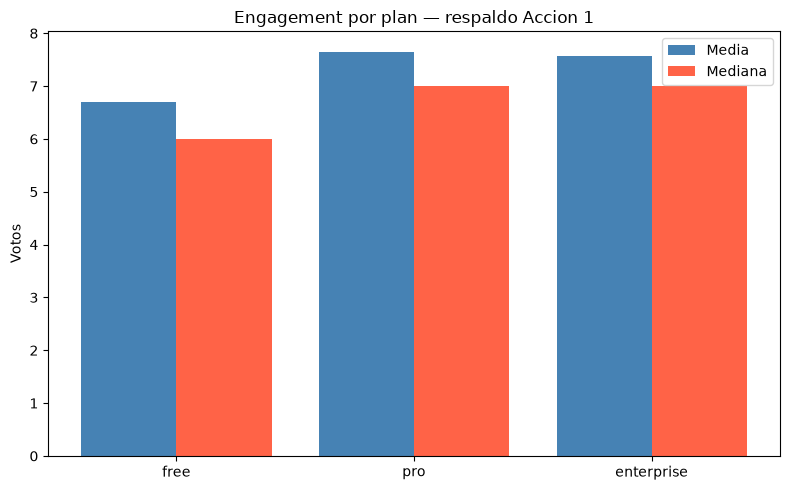

In [90]:
# Gráfico de respaldo — Media vs Mediana por plan
planes = ['free', 'pro', 'enterprise']
medias = []
medianas = []

for plan in planes:
    sub = df_core[df_core['plan_type'] == plan]['votes_received']
    medias.append(sub.mean())
    medianas.append(sub.median())

x = range(len(planes))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], medias, width=0.4, label='Media', color='steelblue')
plt.bar([i + 0.2 for i in x], medianas, width=0.4, label='Mediana', color='tomato')
plt.xticks(x, planes)
plt.title('Engagement por plan — respaldo Accion 1')
plt.ylabel('Votos')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_accion1.png')
plt.show()

**Plan de acción 1:**
- **Qué:** período de prueba de Pro (30 días) a usuarios Free con más de 5 posts
- **Cómo:** notificación in-app y email
- **Métrica de éxito:** tasa de conversión Free → Pro y votos promedio de los convertidos

**Limitación:** no tenemos datos de revenue por usuario ni fecha de cambio de plan.


In [91]:
# ACCIÓN 2 — Retención de Power Users (top 1%)
# Respaldo: tabla de concentración

print('Respaldo Accion 2 — concentracion de actividad:')
print()
print('Top 1% ->', top1_cantidad, 'usuarios')
print('  genera el', round(pct_posts, 1), '% de los posts')
print('  recibe el', round(pct_votos, 1), '% de los votos')
print()
print('Resto 99% ->', total_usuarios - top1_cantidad, 'usuarios')
print('  genera el', round(100 - pct_posts, 1), '% de los posts')
print('  recibe el', round(100 - pct_votos, 1), '% de los votos')

Respaldo Accion 2 — concentracion de actividad:

Top 1% -> 19 usuarios
  genera el 5.4 % de los posts
  recibe el 6.2 % de los votos

Resto 99% -> 1977 usuarios
  genera el 94.6 % de los posts
  recibe el 93.8 % de los votos


**Plan de acción 2:**
- **Qué:** badge de power user, mayor visibilidad en el feed, acceso anticipado a features
- **Cómo:** implementación gradual empezando por el top 1%
- **Métrica de éxito:** retención mensual del top 1% antes y después del programa

**Limitación:** no sabemos si los power users son orgánicos o artificiales.


## Conclusiones

- Cerca del 15% de filas tenían algún problema — typos, fechas imposibles o valores fuera de diccionario.
- `days_since_signup` fue recalculado porque el 26.7% de los valores no coincidía con las fechas reales.
- `user_age` tenía nulos y fue corregido de float a Int64.
- 650 usuarios aparecen con más de un plan — no es un error, cambiaron de plan en el tiempo.
- `user_total_posts` estaba desactualizado en 164 usuarios.
- El promedio a nivel evento es distinto al promedio a nivel usuario — depende de lo que querés medir.
- El top 1% genera una parte desproporcionada de la actividad de la plataforma.
- El segmento Pro es el de mayor oportunidad para crecer.


## 📦 Exportación de Archivos

In [92]:
# Dataset limpio
df_core.to_csv('clean_product_activity.csv', index=False)
print('clean_product_activity.csv guardado:', len(df_core), 'filas')

# Dataset quarantine
df_quarantine_final.to_csv('quarantine_product_activity.csv', index=False)
print('quarantine_product_activity.csv guardado:', len(df_quarantine_final), 'filas')

# Métricas principales
metrics_df = pd.DataFrame()
metrics_df['usuarios_unicos'] = df_core.drop_duplicates('user_id').groupby('plan_type')['user_id'].count()
metrics_df['n_posts'] = df_core.groupby('plan_type')['post_id'].count()
metrics_df['votes_mean'] = df_core.groupby('plan_type')['votes_received'].mean().round(2)
metrics_df['votes_median'] = df_core.groupby('plan_type')['votes_received'].median()
metrics_df['votes_p75'] = df_core.groupby('plan_type')['votes_received'].quantile(0.75)
metrics_df['votes_p90'] = df_core.groupby('plan_type')['votes_received'].quantile(0.90)

metrics_df.to_csv('metrics_summary.csv')
print('metrics_summary.csv guardado')
print()
print(metrics_df)

clean_product_activity.csv guardado: 8509 filas
quarantine_product_activity.csv guardado: 273 filas
metrics_summary.csv guardado

            usuarios_unicos  n_posts  votes_mean  votes_median  votes_p75  \
plan_type                                                                   
enterprise               82      333        7.57           7.0       10.0   
free                   1547     6569        6.69           6.0        9.0   
pro                     367     1607        7.65           7.0       10.0   

            votes_p90  
plan_type              
enterprise       14.0  
free             13.0  
pro              14.0  
